# **SQL Database Agent**

In [2]:
from langchain_community.utilities.sql_database import SQLDatabase

sql_db = SQLDatabase.from_uri("sqlite:///SalesDB/sales.db")

In [3]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
import os
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_openai import ChatOpenAI



load_dotenv()


if os.environ.get("OPENAI_API_KEY") :
    print("Bro API key variable is found")

else :
    raise ValueError("OPENAI_APKI_KEY not found")

llm_openai = ChatOpenAI(model="gpt-5-mini", temperature=0)

Bro API key variable is found


In [4]:
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=sql_db,llm=llm_openai )
toolkit.get_tools()

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000002ADF6EFD940>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000002ADF6EFD940>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000002ADF6EFD940>),
 QuerySQLCheckerTool(description='Use this tool to 

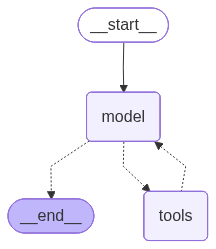

In [5]:
from langchain.agents import create_agent

agent = create_agent(llm_openai, toolkit.get_tools())
agent

In [8]:
example_query = "how much was the total sales in Mumbai?"

events = agent.stream(
    {"messages" : [("user", example_query)]},
    stream_mode="values",
)

for event in events :
    event["messages"][-1].pretty_print()

================================ Human Message =================================

how much was the total sales in Mumbai?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_OL0xW8MV8wVhATgn84PnmUKc)
 Call ID: call_OL0xW8MV8wVhATgn84PnmUKc
  Args:
    tool_input:
================================= Tool Message =================================
Name: sql_db_list_tables

orders
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_aF9see0FmHw28vT6ebnG3oYY)
 Call ID: call_aF9see0FmHw28vT6ebnG3oYY
  Args:
    table_names: orders
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE orders (
	order_id INTEGER, 
	product_name TEXT NOT NULL, 
	product_price REAL NOT NULL, 
	quantity INTEGER NOT NULL, 
	city TEXT NOT NULL, 
	order_date TEXT NOT NULL, 
	PRIMARY KEY (order_id)
)

/*
3 rows from orders table:
